In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import joblib
warnings.filterwarnings('ignore')

In [2]:

df = pd.read_csv('../Data/Crop_recommendation.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
print("Dataset Info:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB

Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [4]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [5]:
print("Target Variable Distribution (Crop Types):")
df["label"].value_counts()

Target Variable Distribution (Crop Types):


label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

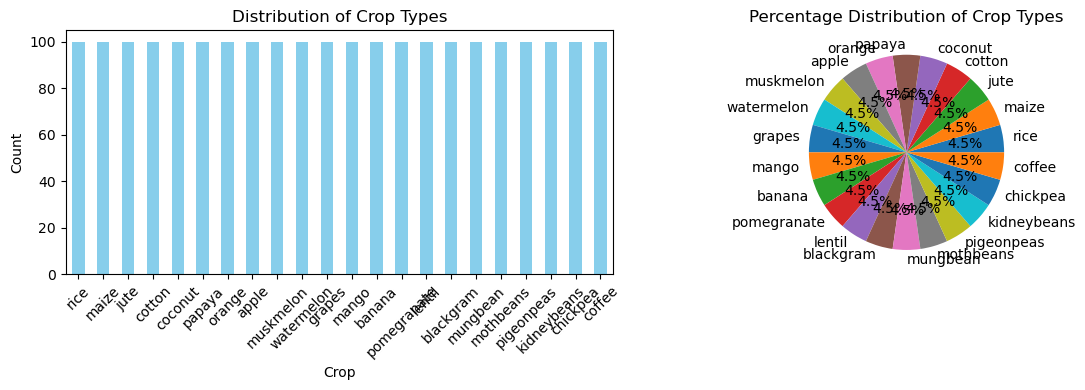

In [6]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df["label"].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Crop Types')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df["label"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Percentage Distribution of Crop Types')
plt.ylabel('')
plt.tight_layout()
plt.show()

Correlation Matrix:


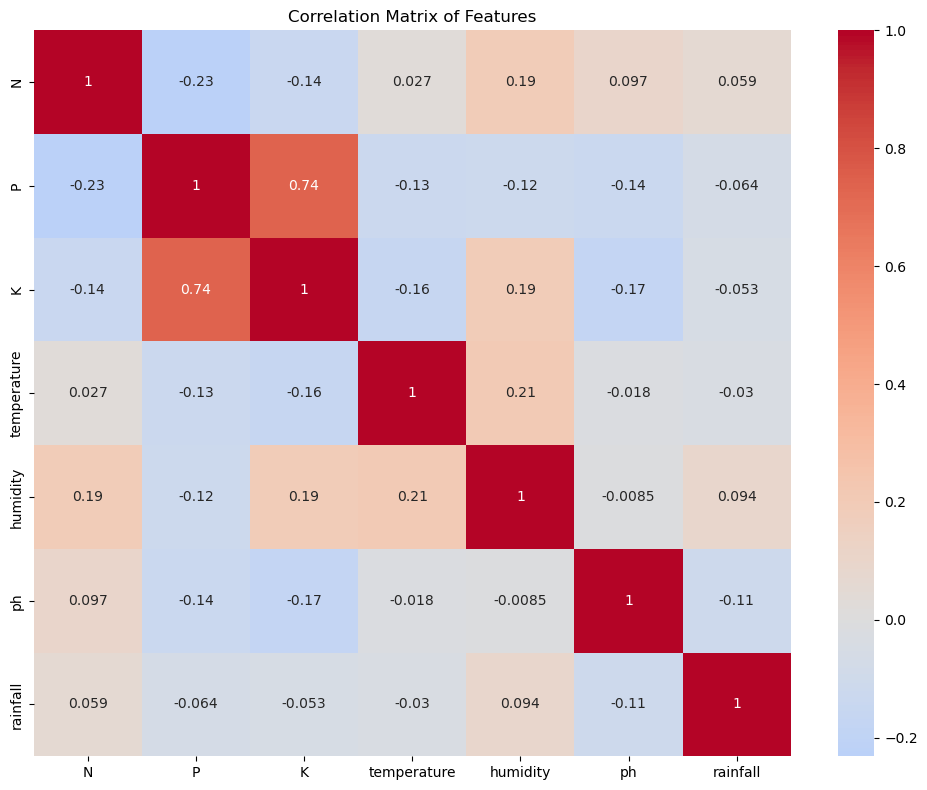

In [7]:
print("Correlation Matrix:")
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()

In [8]:

X = df.drop('label', axis=1)
y = df['label']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target unique values:", y.unique())

Features shape: (2200, 7)
Target shape: (2200,)
Target unique values: ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [9]:
# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label Encoding Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label}: {i}")
    
print("\nEncoded target shape:", y_encoded.shape)

Label Encoding Mapping:
  apple: 0
  banana: 1
  blackgram: 2
  chickpea: 3
  coconut: 4
  coffee: 5
  cotton: 6
  grapes: 7
  jute: 8
  kidneybeans: 9
  lentil: 10
  maize: 11
  mango: 12
  mothbeans: 13
  mungbean: 14
  muskmelon: 15
  orange: 16
  papaya: 17
  pigeonpeas: 18
  pomegranate: 19
  rice: 20
  watermelon: 21

Encoded target shape: (2200,)


In [10]:
# Spliting data into training and testing sets (70-30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining target distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for crop, count in zip(unique, counts):
    print(f"  Class {crop}: {count}")

Training set size: (1540, 7)
Testing set size: (660, 7)

Training target distribution:
  Class 0: 70
  Class 1: 70
  Class 2: 70
  Class 3: 70
  Class 4: 70
  Class 5: 70
  Class 6: 70
  Class 7: 70
  Class 8: 70
  Class 9: 70
  Class 10: 70
  Class 11: 70
  Class 12: 70
  Class 13: 70
  Class 14: 70
  Class 15: 70
  Class 16: 70
  Class 17: 70
  Class 18: 70
  Class 19: 70
  Class 20: 70
  Class 21: 70


In [11]:
# Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Features - Training set shape:", X_train_scaled.shape)
print("Scaled Features - Testing set shape:", X_test_scaled.shape)
print("\nScaled features mean (should be close to 0):", np.mean(X_train_scaled, axis=0))
print("Scaled features std (should be close to 1):", np.std(X_train_scaled, axis=0))

Scaled Features - Training set shape: (1540, 7)
Scaled Features - Testing set shape: (660, 7)

Scaled features mean (should be close to 0): [ 4.84460956e-17  5.07530526e-17  2.99904401e-17  3.64499196e-16
 -1.37263938e-16 -9.58828976e-16 -9.22782774e-17]
Scaled features std (should be close to 1): [1. 1. 1. 1. 1. 1. 1.]


In [12]:
# K-Fold cross-validation (Stratified) for model comparison
print("\nK-fold cross-validation (k=5) results:")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', solver='lbfgs'),
    'Decision Tree': DecisionTreeClassifier(max_depth=15, random_state=42, min_samples_split=5, min_samples_leaf=2),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, min_samples_split=5, min_samples_leaf=2, n_jobs=-1),
    'Support Vector Machine': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='auto')
}

for name, model in models_cv.items():
    # use scaled features for all models
    scores = cross_val_score(model, scaler.transform(X), y_encoded, cv=skf, scoring='accuracy', n_jobs=-1)
    print(f"{name}: mean={scores.mean():.4f}, std={scores.std():.4f}")

# We can keep best model from these results; for now we continue with the previously selected best based on holdout test split.



K-fold cross-validation (k=5) results:
Logistic Regression: mean=0.9714, std=0.0018
Decision Tree: mean=0.9850, std=0.0053
Random Forest: mean=0.9959, std=0.0030
Support Vector Machine: mean=0.9836, std=0.0044
K-Nearest Neighbors: mean=0.9718, std=0.0068


### Logistic Regression

In [13]:

# Train Logistic Regression Classifier (requires scaled features)
lr_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', solver='lbfgs')
lr_model.fit(X_train_scaled, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test_scaled)

# Evaluate
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average='weighted')
lr_recall = recall_score(y_test, lr_pred, average='weighted')
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")

Accuracy:  0.9727
Precision: 0.9735
Recall:    0.9727
F1 Score:  0.9725



Logistic Regression Confusion Matrix:


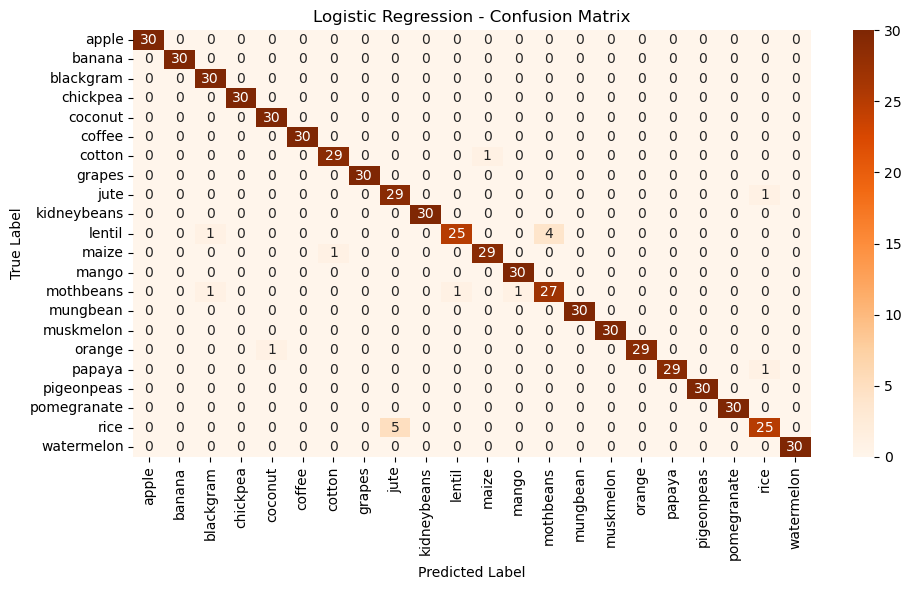


Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        30
      banana       1.00      1.00      1.00        30
   blackgram       0.94      1.00      0.97        30
    chickpea       1.00      1.00      1.00        30
     coconut       0.97      1.00      0.98        30
      coffee       1.00      1.00      1.00        30
      cotton       0.97      0.97      0.97        30
      grapes       1.00      1.00      1.00        30
        jute       0.85      0.97      0.91        30
 kidneybeans       1.00      1.00      1.00        30
      lentil       0.96      0.83      0.89        30
       maize       0.97      0.97      0.97        30
       mango       0.97      1.00      0.98        30
   mothbeans       0.87      0.90      0.89        30
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        30
      orange       1.00      0.97      0.98        30
   

In [14]:
print("\nLogistic Regression Confusion Matrix:")
lr_cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(10, 6))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Oranges', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=label_encoder.classes_))

### Random Forest

In [15]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, 
                                   min_samples_split=5, min_samples_leaf=2, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test_scaled)

# Evaluate
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average='weighted')
rf_recall = recall_score(y_test, rf_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")

# Feature importance
print("\nTop 5 Important Features:")
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance_rf.head())

Accuracy:  0.9939
Precision: 0.9942
Recall:    0.9939
F1 Score:  0.9939

Top 5 Important Features:
    Feature  Importance
6  rainfall    0.230357
4  humidity    0.207835
2         K    0.181854
1         P    0.153549
0         N    0.105955



Random Forest Confusion Matrix:


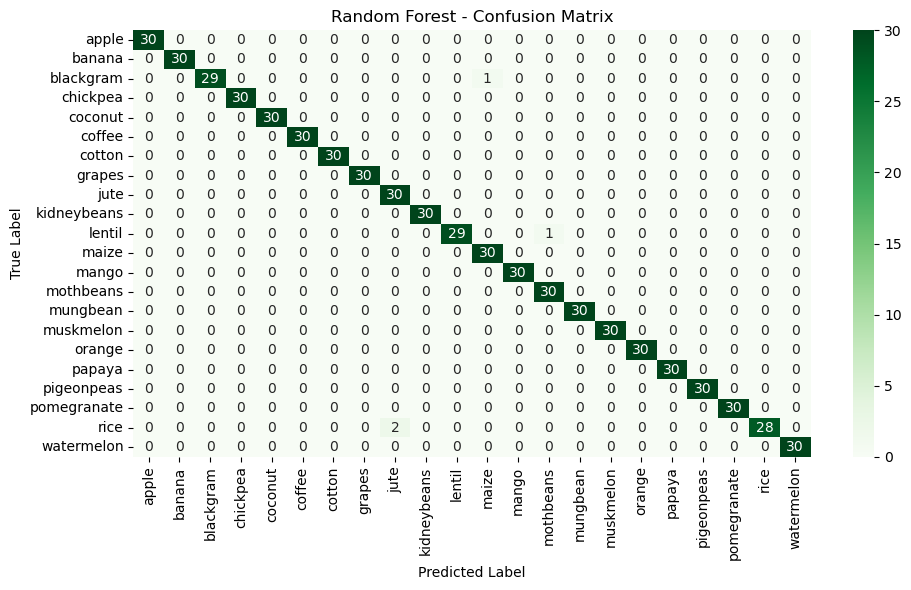


Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        30
      banana       1.00      1.00      1.00        30
   blackgram       1.00      0.97      0.98        30
    chickpea       1.00      1.00      1.00        30
     coconut       1.00      1.00      1.00        30
      coffee       1.00      1.00      1.00        30
      cotton       1.00      1.00      1.00        30
      grapes       1.00      1.00      1.00        30
        jute       0.94      1.00      0.97        30
 kidneybeans       1.00      1.00      1.00        30
      lentil       1.00      0.97      0.98        30
       maize       0.97      1.00      0.98        30
       mango       1.00      1.00      1.00        30
   mothbeans       0.97      1.00      0.98        30
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        30
      orange       1.00      1.00      1.00        30
   

In [16]:
print("\nRandom Forest Confusion Matrix:")
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(10, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))

### Decision Tree Classifier

In [17]:


# Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=15, random_state=42, min_samples_split=5, min_samples_leaf=2)
dt_model.fit(X_train, y_train)

# Make predictions
dt_pred = dt_model.predict(X_test)

# Evaluate
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred, average='weighted')
dt_recall = recall_score(y_test, dt_pred, average='weighted')
dt_f1 = f1_score(y_test, dt_pred, average='weighted')

print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print(f"F1 Score:  {dt_f1:.4f}")

# Feature importance
print("\nTop 5 Important Features:")
feature_importance_dt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance_dt.head())

Accuracy:  0.9742
Precision: 0.9754
Recall:    0.9742
F1 Score:  0.9741

Top 5 Important Features:
       Feature  Importance
6     rainfall    0.356219
1            P    0.227857
4     humidity    0.213683
2            K    0.095705
3  temperature    0.051256



Decision Tree Confusion Matrix:


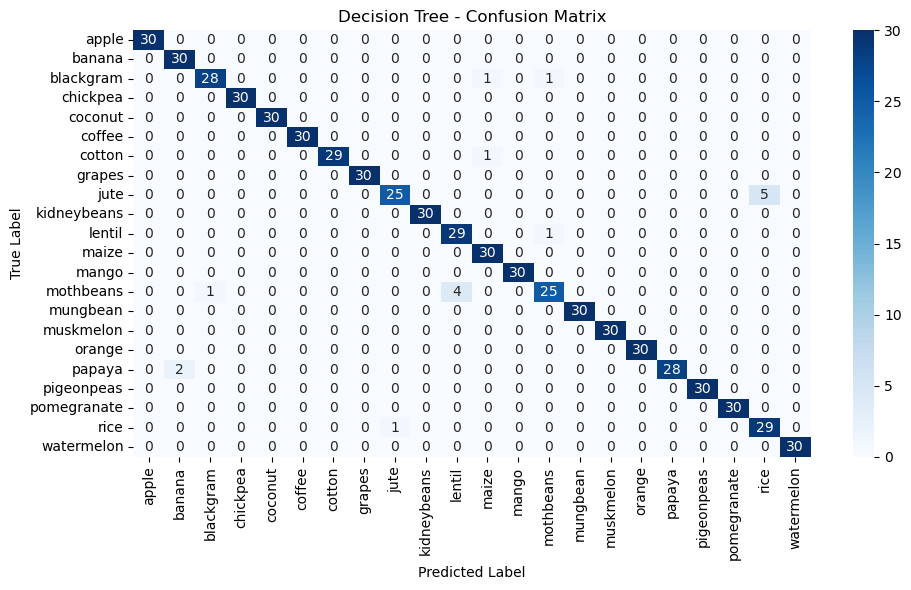


Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        30
      banana       0.94      1.00      0.97        30
   blackgram       0.97      0.93      0.95        30
    chickpea       1.00      1.00      1.00        30
     coconut       1.00      1.00      1.00        30
      coffee       1.00      1.00      1.00        30
      cotton       1.00      0.97      0.98        30
      grapes       1.00      1.00      1.00        30
        jute       0.96      0.83      0.89        30
 kidneybeans       1.00      1.00      1.00        30
      lentil       0.88      0.97      0.92        30
       maize       0.94      1.00      0.97        30
       mango       1.00      1.00      1.00        30
   mothbeans       0.93      0.83      0.88        30
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        30
      orange       1.00      1.00      1.00        30
   

In [18]:
print("\nDecision Tree Confusion Matrix:")
dt_cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(10, 6))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Decision Tree - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=label_encoder.classes_))

### Support Vector Machine

In [19]:
# Train Support Vector Machine Classifier
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Make predictions
svm_pred = svm_model.predict(X_test_scaled)

# Evaluate
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average='weighted')
svm_recall = recall_score(y_test, svm_pred, average='weighted')
svm_f1 = f1_score(y_test, svm_pred, average='weighted')

print(f"Accuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1 Score:  {svm_f1:.4f}")

Accuracy:  0.9894
Precision: 0.9903
Recall:    0.9894
F1 Score:  0.9894



Support Vector Machine Confusion Matrix:


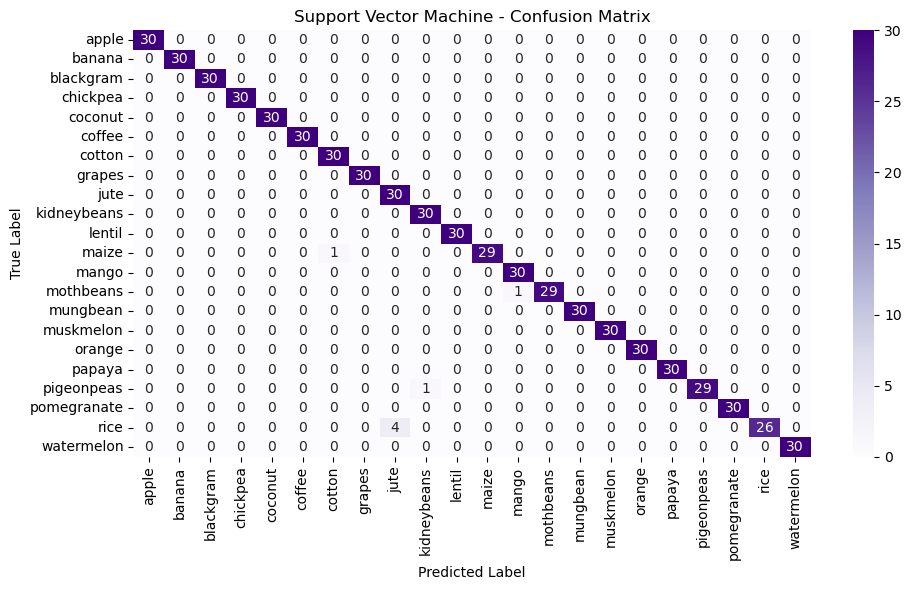


Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        30
      banana       1.00      1.00      1.00        30
   blackgram       1.00      1.00      1.00        30
    chickpea       1.00      1.00      1.00        30
     coconut       1.00      1.00      1.00        30
      coffee       1.00      1.00      1.00        30
      cotton       0.97      1.00      0.98        30
      grapes       1.00      1.00      1.00        30
        jute       0.88      1.00      0.94        30
 kidneybeans       0.97      1.00      0.98        30
      lentil       1.00      1.00      1.00        30
       maize       1.00      0.97      0.98        30
       mango       0.97      1.00      0.98        30
   mothbeans       1.00      0.97      0.98        30
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        30
      orange       1.00      1.00      1.00        30
   

In [20]:
print("\nSupport Vector Machine Confusion Matrix:")
svm_cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(10, 6))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Purples', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Support Vector Machine - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, svm_pred, target_names=label_encoder.classes_))

### K-Nearest Neighbors

In [21]:
# Train K-Nearest Neighbors Classifier
knn_model = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='auto')
knn_model.fit(X_train_scaled, y_train)

# Make predictions
knn_pred = knn_model.predict(X_test_scaled)

# Evaluate
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, average='weighted')
knn_recall = recall_score(y_test, knn_pred, average='weighted')
knn_f1 = f1_score(y_test, knn_pred, average='weighted')

print(f"Accuracy:  {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall:    {knn_recall:.4f}")
print(f"F1 Score:  {knn_f1:.4f}")

Accuracy:  0.9788
Precision: 0.9801
Recall:    0.9788
F1 Score:  0.9786



K-Nearest Neighbors Confusion Matrix:


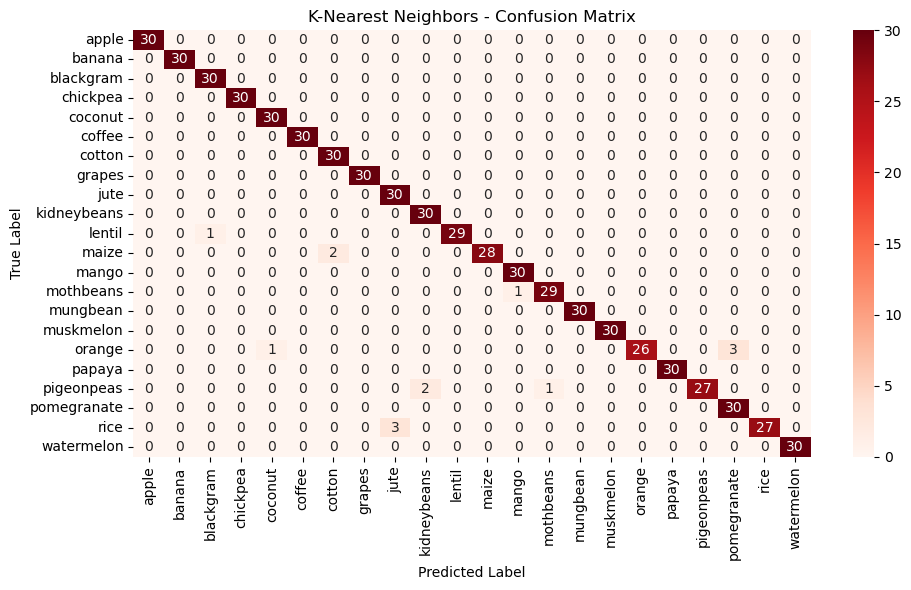


Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        30
      banana       1.00      1.00      1.00        30
   blackgram       0.97      1.00      0.98        30
    chickpea       1.00      1.00      1.00        30
     coconut       0.97      1.00      0.98        30
      coffee       1.00      1.00      1.00        30
      cotton       0.94      1.00      0.97        30
      grapes       1.00      1.00      1.00        30
        jute       0.91      1.00      0.95        30
 kidneybeans       0.94      1.00      0.97        30
      lentil       1.00      0.97      0.98        30
       maize       1.00      0.93      0.97        30
       mango       0.97      1.00      0.98        30
   mothbeans       0.97      0.97      0.97        30
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        30
      orange       1.00      0.87      0.93        30
   

In [22]:
print("\nK-Nearest Neighbors Confusion Matrix:")
knn_cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(10, 6))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Reds', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('K-Nearest Neighbors - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, knn_pred, target_names=label_encoder.classes_))

                 Model  Accuracy  Precision   Recall  F1 Score
         Decision Tree  0.974242   0.975441 0.974242  0.974097
         Random Forest  0.993939   0.994227 0.993939  0.993935
   Logistic Regression  0.972727   0.973531 0.972727  0.972543
Support Vector Machine  0.989394   0.990254 0.989394  0.989366
   K-Nearest Neighbors  0.978788   0.980140 0.978788  0.978619


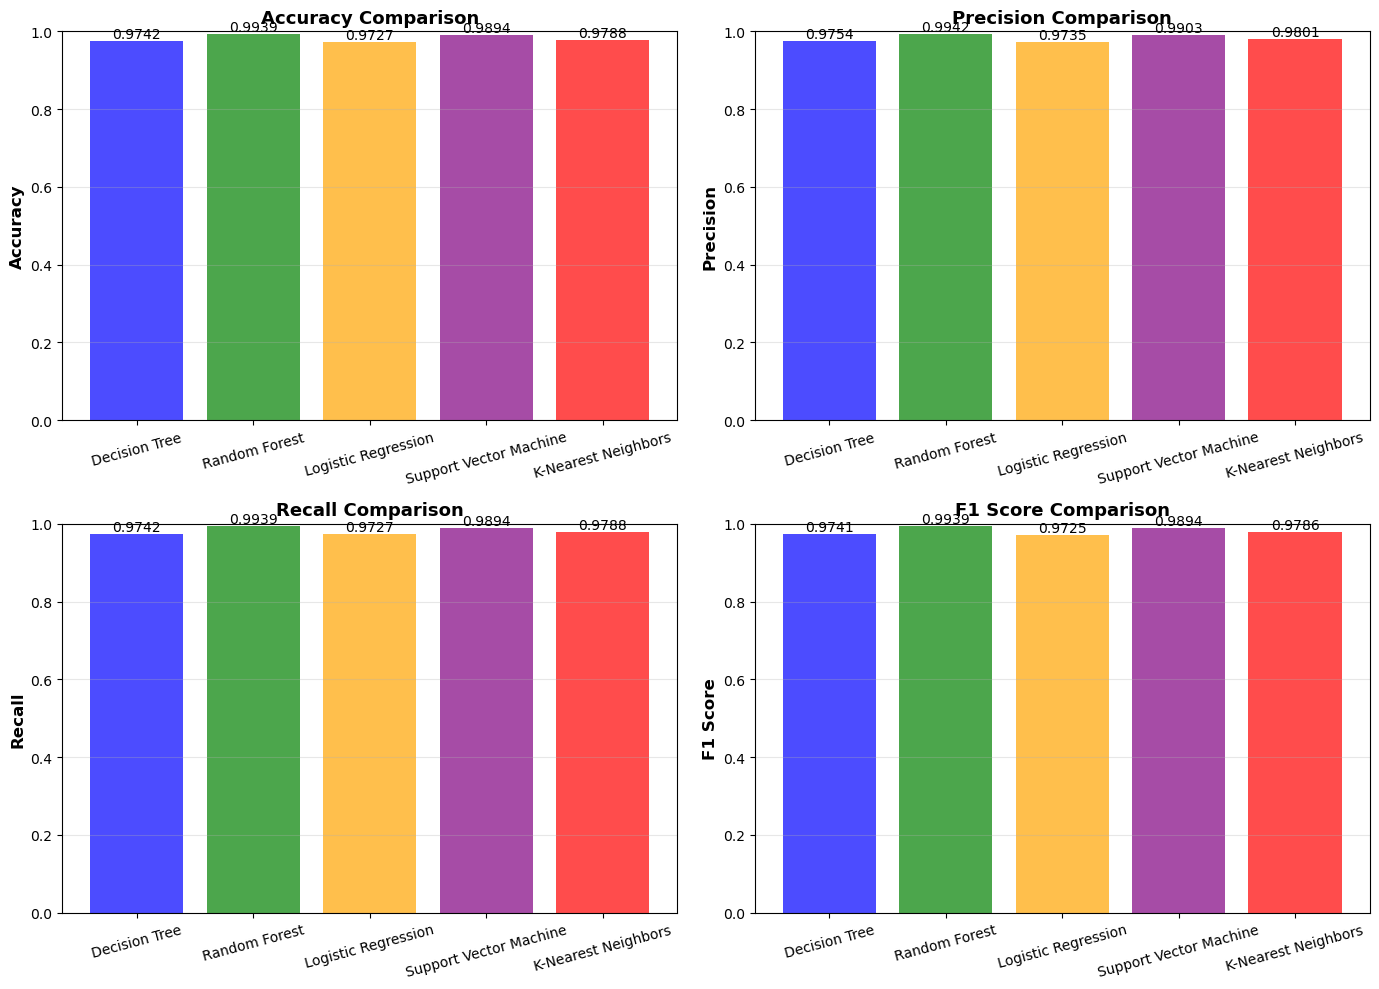

In [23]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression', 'Support Vector Machine', 'K-Nearest Neighbors'],
    'Accuracy': [dt_accuracy, rf_accuracy, lr_accuracy, svm_accuracy, knn_accuracy],
    'Precision': [dt_precision, rf_precision, lr_precision, svm_precision, knn_precision],
    'Recall': [dt_recall, rf_recall, lr_recall, svm_recall, knn_recall],
    'F1 Score': [dt_f1, rf_f1, lr_f1, svm_f1, knn_f1]
})

print(comparison_df.to_string(index=False))

# Visualize comparison
colors = ['blue', 'green', 'orange', 'purple', 'red']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = comparison_df[metric].values
    x_pos = np.arange(len(comparison_df))
    bars = ax.bar(x_pos, values, color=colors, alpha=0.7)
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(comparison_df['Model'], rotation=15)
    ax.set_ylim([0, 1])
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Select the best model based on accuracy
best_model_idx = comparison_df['Accuracy'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_accuracy = comparison_df.loc[best_model_idx, 'Accuracy']

print(f"Best Model: {best_model_name} with Accuracy: {best_accuracy:.4f}")

# Map model names to model objects
model_dict = {
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Logistic Regression': lr_model,
    'Support Vector Machine': svm_model,
    'K-Nearest Neighbors': knn_model
}

best_model = model_dict[best_model_name]

# For scaled models, we need to check if it uses scaled features
scaled_models = ['Logistic Regression', 'Support Vector Machine', 'K-Nearest Neighbors', 'Random Forest']
uses_scaled = best_model_name in scaled_models

Best Model: Random Forest with Accuracy: 0.9939


In [25]:
# Save important components for future use
import os
if not os.path.exists('../models'):
    os.makedirs('../models')

joblib.dump(best_model, '../models/model1/best_crop_model.pkl')
joblib.dump(scaler, '../models/model1/scaler.pkl')
joblib.dump(label_encoder, '../models/model1/label_encoder.pkl')

print("Saved components:")
print("- Best model: ../models/best_crop_model.pkl")
print("- Scaler: ../models/scaler.pkl")
print("- Label encoder: ../models/label_encoder.pkl")

# Also save model metadata
import json
metadata = {
    'best_model': best_model_name,
    'accuracy': best_accuracy,
    'uses_scaled_features': uses_scaled,
    'features': list(X.columns),
    'classes': list(label_encoder.classes_)
}

with open('../models//model1/model_metadata_updated.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("- Model metadata: ../models/model_metadata_updated.json")

Saved components:
- Best model: ../models/best_crop_model.pkl
- Scaler: ../models/scaler.pkl
- Label encoder: ../models/label_encoder.pkl
- Model metadata: ../models/model_metadata_updated.json


In [26]:
# Example of loading and using saved model
# loaded_model = joblib.load('../models/best_crop_model.pkl')
# loaded_scaler = joblib.load('../models/scaler.pkl')
# loaded_encoder = joblib.load('../models/label_encoder.pkl')

# Then use the recommend_crops function with loaded_model, loaded_scaler, loaded_encoder

print("To use in production:")
print("1. Load the saved model, scaler, and encoder")
print("2. Use the recommend_crops function with loaded components")
print("3. Pass the environmental parameters to get top 4 crop recommendations")

To use in production:
1. Load the saved model, scaler, and encoder
2. Use the recommend_crops function with loaded components
3. Pass the environmental parameters to get top 4 crop recommendations


In [27]:
# Function to recommend top 4 crops
def recommend_crops(N, P, K, temperature, humidity, ph, rainfall, model=best_model, scaler=scaler, label_encoder=label_encoder, top_n=4, uses_scaled=uses_scaled):
    features = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    if uses_scaled:
        features_scaled = scaler.transform(features)
        proba = model.predict_proba(features_scaled)[0]
    else:
        proba = model.predict_proba(features)[0]
    
    top_indices = np.argsort(proba)[-top_n:][::-1]
    recommendations = []
    for idx in top_indices:
        crop = label_encoder.inverse_transform([idx])[0]
        prob = proba[idx]
        recommendations.append((crop, round(prob * 100, 2)))
    return recommendations

In [28]:
# Example usage: Recommend crops for given conditions
# Sample input: N=90, P=42, K=43, temperature=20.879744, humidity=82.002744, ph=6.502985, rainfall=202.935536
sample_N = 45
sample_P = 42
sample_K = 43
sample_temperature = 20.879744
sample_humidity = 82.002744
sample_ph = 6.502985
sample_rainfall = 202.935536

recommendations = recommend_crops(sample_N, sample_P, sample_K, sample_temperature, sample_humidity, sample_ph, sample_rainfall)

print("Top 4 Crop Recommendations:")
for i, (crop, prob) in enumerate(recommendations, 1):
    print(f"{i}. {crop}: {prob}%")

Top 4 Crop Recommendations:
1. papaya: 39.02%
2. rice: 30.69%
3. pomegranate: 14.5%
4. mungbean: 5.0%
